# Libs

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot Style

In [2]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#e5e5e0",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#52514e",
    "text.color": "#0b0b0b",
    "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLOR_EXISTING = "#2a78d6"  # categorical slot 1 (blue)
COLOR_NEW = "#eb6834"  # categorical slot 2 (orange)
COLOR_NEUTRAL = "#8a8a85"  # muted reference lines
SEQUENTIAL_BLUES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]

# Helpers

In [3]:
def find_non_product_codes(df):
    """Find StockCodes that do not look like real products.

    Normal Online Retail II product codes start with a digit
    (e.g. "85048", "79323P"). Codes that start with a letter are
    operational codes such as postage or bank charges rather than
    products.

    Args:
        df: Transaction DataFrame with a product_id column.

    Returns:
        A sorted list of the anomalous product_id values.
    """
    codes = df["product_id"].unique()
    anomalous = [c for c in codes if not c[:1].isdigit()]
    return sorted(anomalous)


def flag_valid_transactions(df, non_product_codes):
    """Flag rows that count as a valid purchase.

    A valid purchase keeps a Customer ID, is not a cancellation
    (Invoice starting with "C"), has Quantity > 0 and Price > 0,
    is not a non-product stock code, and is not an exact duplicate
    of an earlier row.

    Args:
        df: Transaction DataFrame with renamed columns
            (invoice_id, customer_id, quantity, unit_price,
            product_id).
        non_product_codes: Collection of product_id values to
            exclude (e.g. from find_non_product_codes).

    Returns:
        A boolean Series aligned to df.index, True for valid rows.
    """
    has_customer = df["customer_id"].notna()
    not_cancelled = ~df["invoice_id"].str.startswith("C")
    valid_amounts = (df["quantity"] > 0) & (df["unit_price"] > 0)
    is_product = ~df["product_id"].isin(non_product_codes)
    not_duplicate = ~df.duplicated()
    return (
        has_customer
        & not_cancelled
        & valid_amounts
        & is_product
        & not_duplicate
    )

In [4]:
def compute_occasions(df):
    """Collapse valid transactions to one row per purchase occasion.

    A purchase occasion is one distinct invoice. Revenue is summed
    across the invoice's lines and the timestamp is the invoice's
    earliest line.

    Args:
        df: Valid transaction rows with customer_id, invoice_id,
            invoice_time and total_price columns.

    Returns:
        DataFrame with one row per (customer_id, invoice_id):
        customer_id, invoice_id, invoice_time, revenue.
    """
    occasions = (
        df.groupby(["customer_id", "invoice_id"], as_index=False)
        .agg(
            invoice_time=("invoice_time", "min"),
            revenue=("total_price", "sum"),
        )
        .sort_values(["customer_id", "invoice_time"])
        .reset_index(drop=True)
    )
    return occasions


def compute_order_seq(occasions):
    """Add order sequence and new/existing customer_type flags.

    Args:
        occasions: Purchase-occasion table with customer_id and
            invoice_time columns.

    Returns:
        A copy of occasions with two new columns: order_seq (1 for
        a customer's first occasion) and customer_type ("new" for
        order_seq == 1, "existing" otherwise).
    """
    occasions = occasions.sort_values(
        ["customer_id", "invoice_time"]
    ).copy()
    occasions["order_seq"] = (
        occasions.groupby("customer_id").cumcount() + 1
    )
    occasions["customer_type"] = np.where(
        occasions["order_seq"] == 1, "new", "existing"
    )
    return occasions

In [5]:
def inter_purchase_intervals(occasions):
    """Compute gaps in days between a customer's consecutive
    occasions.

    Args:
        occasions: Purchase-occasion table with customer_id and
            invoice_time columns.

    Returns:
        A Series of gap lengths in days (float). Customers with a
        single occasion contribute no rows.
    """
    ordered = occasions.sort_values(["customer_id", "invoice_time"])
    gap_seconds = ordered.groupby("customer_id")["invoice_time"].diff()
    gap_days = gap_seconds.dt.total_seconds() / 86400
    return gap_days.dropna()

In [6]:
def build_snapshot_grid(occasions, snapshot_dates, r_max):
    """Build a Customer x Snapshot Date grid with recency.

    For every customer and every snapshot date, the most recent
    purchase on or before that date is looked up with a backward
    as-of merge. A customer with no purchase on or before the date
    is dropped (not yet an existing customer at that snapshot).

    Args:
        occasions: Purchase-occasion table with customer_id and
            invoice_time columns.
        snapshot_dates: Iterable of snapshot Timestamps (e.g. a
            weekly or daily date range).
        r_max: Activity threshold in days; rows with
            recency_days <= r_max are flagged active.

    Returns:
        DataFrame with one row per (customer_id, snapshot_date) for
        customers with purchase history by that date: customer_id,
        snapshot_date, last_purchase_time, recency_days, is_active.
    """
    customers = pd.DataFrame(
        {"customer_id": occasions["customer_id"].unique()}
    )
    dates = pd.DataFrame({"snapshot_date": snapshot_dates})
    grid = customers.merge(dates, how="cross")
    grid = grid.sort_values("snapshot_date")

    history = occasions[["customer_id", "invoice_time"]].sort_values(
        "invoice_time"
    )
    grid = pd.merge_asof(
        grid,
        history,
        left_on="snapshot_date",
        right_on="invoice_time",
        by="customer_id",
        direction="backward",
    )
    grid = grid.dropna(subset=["invoice_time"]).rename(
        columns={"invoice_time": "last_purchase_time"}
    )
    recency = grid["snapshot_date"] - grid["last_purchase_time"]
    grid["recency_days"] = recency.dt.total_seconds() / 86400
    grid["is_active"] = grid["recency_days"] <= r_max
    return grid.sort_values(
        ["customer_id", "snapshot_date"]
    ).reset_index(drop=True)

In [7]:
def add_provisional_labels(grid, occasions, horizon, data_end):
    """Add a provisional churn label to each labelable snapshot row.

    A row is labelable only if its full prediction window is
    observed, i.e. snapshot_date + horizon <= data_end. For those
    rows, a forward as-of merge finds the next purchase after the
    snapshot date; churn = 1 if no purchase falls within the
    (snapshot_date, snapshot_date + horizon] window.

    Args:
        grid: Output of build_snapshot_grid.
        occasions: Purchase-occasion table with customer_id and
            invoice_time columns.
        horizon: Prediction horizon in days (H).
        data_end: Timestamp of the last observed transaction.

    Returns:
        The subset of grid restricted to labelable rows, with two
        new columns: next_purchase_time and churn (0/1 int).
    """
    window = pd.Timedelta(days=horizon)
    labelable = grid[grid["snapshot_date"] + window <= data_end].copy()
    labelable = labelable.sort_values("snapshot_date")

    history = occasions[["customer_id", "invoice_time"]].sort_values(
        "invoice_time"
    )
    labelable = pd.merge_asof(
        labelable,
        history,
        left_on="snapshot_date",
        right_on="invoice_time",
        by="customer_id",
        direction="forward",
        allow_exact_matches=False,
    )
    labelable = labelable.rename(
        columns={"invoice_time": "next_purchase_time"}
    )
    window_end = labelable["snapshot_date"] + window
    no_purchase = labelable["next_purchase_time"].isna()
    too_late = labelable["next_purchase_time"] > window_end
    labelable["churn"] = (no_purchase | too_late).astype(int)
    return labelable.reset_index(drop=True)

In [8]:
def apply_episode_cooldown(active_grid, cooldown_days):
    """Select one training snapshot per eligibility episode.

    Starting from a customer's first active snapshot date, the next
    training snapshot is the first later active date at least
    cooldown_days after it, and so on. This removes near-duplicate,
    overlapping snapshots from the training population.

    Args:
        active_grid: Active rows (is_active == True) from
            build_snapshot_grid, with customer_id and
            snapshot_date columns.
        cooldown_days: Minimum gap in days between two training
            snapshots of the same customer (C).

    Returns:
        The subset of active_grid rows selected as training
        snapshots.
    """
    cooldown = pd.Timedelta(days=cooldown_days)
    ordered = active_grid.sort_values(["customer_id", "snapshot_date"])
    selected_index = []
    for _, rows in ordered.groupby("customer_id"):
        next_allowed = None
        for row in rows.itertuples():
            allowed = next_allowed is None or row.snapshot_date >= (
                next_allowed
            )
            if allowed:
                selected_index.append(row.Index)
                next_allowed = row.snapshot_date + cooldown
    return active_grid.loc[selected_index]

# Load

In [9]:
if os.path.exists("../data/raw/online_retail_II.parquet"):
    df_retail = pd.read_parquet("../data/raw/online_retail_II.parquet")
else:
    df_2009_2010 = pd.read_excel(
        "../data/raw/online_retail_II.xlsx",
        sheet_name="Year 2009-2010",
    )
    df_2010_2011 = pd.read_excel(
        "../data/raw/online_retail_II.xlsx",
        sheet_name="Year 2010-2011",
    )
    df_retail = pd.concat(
        [df_2009_2010, df_2010_2011], ignore_index=True
    )
    df_retail["Invoice"] = df_retail["Invoice"].astype(str)
    df_retail["StockCode"] = df_retail["StockCode"].astype(str)
    df_retail["Description"] = df_retail["Description"].astype(str)
    df_retail.to_parquet(
        "../data/raw/online_retail_II.parquet", index=False
    )

In [10]:
RENAME_COLUMNS = {
    "Invoice": "invoice_id",
    "StockCode": "product_id",
    "Description": "product_description",
    "Quantity": "quantity",
    "InvoiceDate": "invoice_time",
    "Price": "unit_price",
    "Customer ID": "customer_id",
    "Country": "country",
}
df_retail = df_retail.rename(columns=RENAME_COLUMNS)
df_retail["invoice_time"] = pd.to_datetime(df_retail["invoice_time"])
df_retail["total_price"] = df_retail["quantity"] * df_retail["unit_price"]
df_retail["invoice_month"] = (
    df_retail["invoice_time"].dt.to_period("M").dt.to_timestamp()
)
df_retail.shape

(1067371, 10)

## 6.1 Objective

Determine what the transaction data reveal about sales, customers,
revenue composition, repeat purchasing, behavior, and the
feasibility of churn prediction.

**Note -- iterative link with Chapter 7.** Sections 6.13-6.14 need
churn labels and snapshots, which are formally built in Chapter 7
(Data Preparation). This notebook uses **provisional** labels and
snapshots computed for candidate values of H, R_max and C, purely
for exploration here. Final values and the production pipeline are
fixed in Chapter 7.

## 6.2 Dataset Overview

High-level size and coverage of the raw dataset, before any
cleaning.

In [11]:
overview = pd.Series({
    "transactions": len(df_retail),
    "invoices": df_retail["invoice_id"].nunique(),
    "customers": df_retail["customer_id"].nunique(),
    "products": df_retail["product_id"].nunique(),
    "countries": df_retail["country"].nunique(),
    "total_quantity": int(df_retail["quantity"].sum()),
    "total_revenue": round(df_retail["total_price"].sum(), 2),
    "date_start": df_retail["invoice_time"].min(),
    "date_end": df_retail["invoice_time"].max(),
})
overview

transactions                  1067371
invoices                        53628
customers                        5942
products                         5305
countries                          43
total_quantity               10608492
total_revenue             19287250.57
date_start        2009-12-01 07:45:00
date_end          2011-12-09 12:50:00
dtype: object

In [12]:
df_retail["country"].value_counts().head(10)

country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

## 6.3 Data Quality

Each issue below is measured on the full raw dataset. Non-product
stock codes are discovered empirically (codes that do not start
with a digit, unlike normal product codes such as "85048" or
"79323P") rather than assumed ahead of time.

In [48]:
df_retail[df_retail["product_id"].isin(non_product_codes)]

,invoice_id,product_id,product_description,quantity,invoice_time,unit_price,customer_id,country,total_price,invoice_month
89,489439,POST,POSTAGE,3,2009-12-01 09:28:00,18.00,12682.0,France,54.00,2009-12-01
126,489444,POST,POSTAGE,1,2009-12-01 09:55:00,141.00,12636.0,USA,141.00,2009-12-01
173,489447,POST,POSTAGE,1,2009-12-01 10:10:00,130.00,12362.0,Belgium,130.00,2009-12-01
625,489526,POST,POSTAGE,6,2009-12-01 11:50:00,18.00,12533.0,Germany,108.00,2009-12-01
735,C489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299.0,United Kingdom,-9.00,2009-12-01
...,...,...,...,...,...,...,...,...,...,...
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,-224.69,2011-12-01
1067191,581570,POST,POSTAGE,1,2011-12-09 11:59:00,18.00,12662.0,Germany,18.00,2011-12-01
1067228,581574,POST,POSTAGE,2,2011-12-09 12:09:00,18.00,12526.0,Germany,36.00,2011-12-01
1067229,581578,POST,POSTAGE,3,2011-12-09 12:16:00,18.00,12713.0,Germany,54.00,2011-12-01


In [13]:
non_product_codes = find_non_product_codes(df_retail)
non_product_summary = (
    df_retail[df_retail["product_id"].isin(non_product_codes)]
    .groupby("product_id")
    .agg(
        rows=("product_id", "size"),
        description=("product_description", "first"),
    )
    .sort_values("rows", ascending=False)
)
non_product_summary

,rows,description
product_id,,
POST,2122,POSTAGE
DOT,1446,DOTCOM POSTAGE
M,1421,Manual
C2,282,CARRIAGE
D,177,Discount
...,...,...
DCGS0071,1,nan
DCGS0067,1,ebay
DCGS0066P,1,nan


In [14]:
n_rows = len(df_retail)
quality_issues = pd.Series({
    "missing_customer_id": df_retail["customer_id"].isna().sum(),
    "exact_duplicates": df_retail.duplicated().sum(),
    "invalid_quantity_or_price": (
        (df_retail["quantity"] <= 0) | (df_retail["unit_price"] <= 0)
    ).sum(),
    "cancellations": (
        df_retail["invoice_id"].str.startswith("C")
    ).sum(),
    "non_product_codes": (
        df_retail["product_id"].isin(non_product_codes)
    ).sum(),
})
quality_report = quality_issues.to_frame("rows")
quality_report["share_of_rows"] = (
    quality_report["rows"] / n_rows
).round(4)
quality_report

,rows,share_of_rows
missing_customer_id,243007,0.2277
exact_duplicates,34335,0.0322
invalid_quantity_or_price,25700,0.0241
cancellations,19494,0.0183
non_product_codes,6093,0.0057


`df_valid` below combines all of the rules above into a single
provisional filter for exploration in the rest of this notebook.
The authoritative definition is formalized in Chapter 7 (see
`latex/content/data_preparation.tex`, Section 7.2).

In [15]:
is_valid = flag_valid_transactions(df_retail, non_product_codes)
df_valid = df_retail[is_valid].copy()
print(
    f"Valid rows kept for analysis: {len(df_valid):,} "
    f"({len(df_valid) / n_rows:.1%} of raw rows)"
)

Valid rows kept for analysis: 776,577 (72.8% of raw rows)


## 6.4 Monthly Sales Performance

Monthly customers, invoices, quantity and revenue on valid
transactions, to see sales dynamics and seasonality.

In [16]:
monthly_sales = df_valid.groupby("invoice_month").agg(
    customers=("customer_id", "nunique"),
    invoices=("invoice_id", "nunique"),
    quantity=("quantity", "sum"),
    revenue=("total_price", "sum"),
)
monthly_sales.round(2)

,customers,invoices,quantity,revenue
invoice_month,,,,
2009-12-01,951,1497,398489,677916.07
2010-01-01,701,959,369875,533712.98
2010-02-01,771,1093,371658,497937.57
2010-03-01,1051,1509,501290,665973.67
2010-04-01,939,1315,350030,585127.43
2010-05-01,965,1365,384606,592734.13
2010-06-01,1034,1479,389388,628809.40
2010-07-01,924,1362,324414,581487.96
2010-08-01,910,1276,452168,594561.17


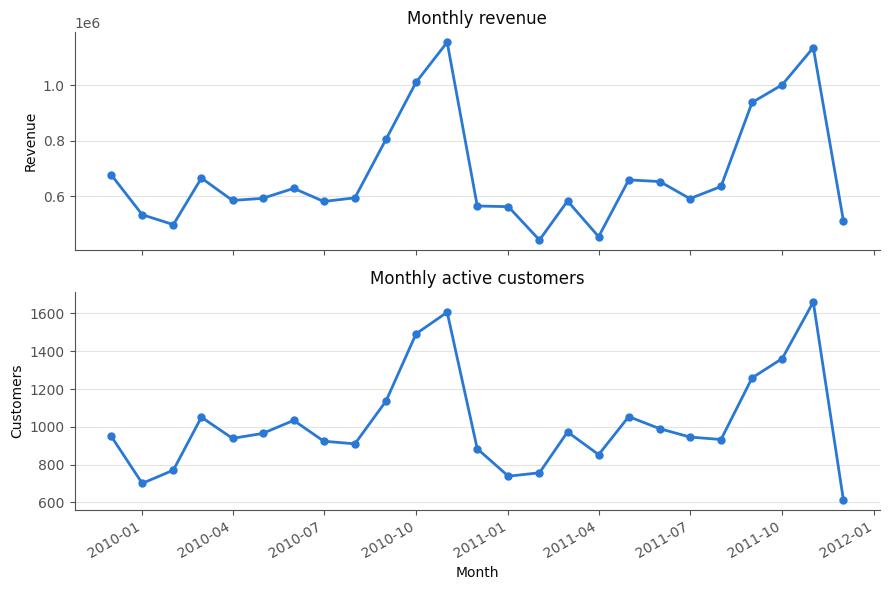

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(
    monthly_sales.index,
    monthly_sales["revenue"],
    color=COLOR_EXISTING,
    linewidth=2,
    marker="o",
    markersize=5,
)
axes[0].set_title("Monthly revenue")
axes[0].set_ylabel("Revenue")

axes[1].plot(
    monthly_sales.index,
    monthly_sales["customers"],
    color=COLOR_EXISTING,
    linewidth=2,
    marker="o",
    markersize=5,
)
axes[1].set_title("Monthly active customers")
axes[1].set_ylabel("Customers")
axes[1].set_xlabel("Month")

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6.5 New vs Existing Customers

Each customer's purchase occasions are ordered in time; the first
occasion is "new", every later one is "existing". Compared
monthly.

In [18]:
occasions = compute_occasions(df_valid)
occasions = compute_order_seq(occasions)
occasions["occasion_month"] = (
    occasions["invoice_time"].dt.to_period("M").dt.to_timestamp()
)
occasions.head()

,customer_id,invoice_id,invoice_time,revenue,order_seq,customer_type,occasion_month
0,12346.0,499763,2010-03-02 13:08:00,27.05,1,new,2010-03-01
1,12346.0,513774,2010-06-28 13:53:00,142.31,2,existing,2010-06-01
2,12346.0,541431,2011-01-18 10:01:00,77183.60,3,existing,2011-01-01
3,12347.0,529924,2010-10-31 14:20:00,611.53,1,new,2010-10-01
4,12347.0,537626,2010-12-07 14:57:00,711.79,2,existing,2010-12-01


In [19]:
monthly_customer_type = (
    occasions.groupby(["occasion_month", "customer_type"])[
        "customer_id"
    ]
    .nunique()
    .reset_index()
    .pivot(
        index="occasion_month",
        columns="customer_type",
        values="customer_id",
    )
    .fillna(0)
    .astype(int)
)
monthly_customer_type.index = monthly_customer_type.index.strftime(
    "%Y-%m"
)
monthly_customer_type.T.style.background_gradient(
    cmap="Blues", axis=1
).format("{:,.0f}")

occasion_month,2009-12,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,2010-11,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
customer_type,,,,,,,,,,,,,,,,,,,,,,,,,
existing,281,379,439,664,669,736,800,771,770,923,"1,161","1,338",811,673,642,813,756,956,897,860,833,"1,094","1,168","1,501",587
new,951,368,375,441,294,255,267,185,163,239,375,326,76,72,125,179,106,111,108,101,107,188,221,191,28


## 6.6 Revenue from New and Existing Customers

In [20]:
monthly_revenue_type = (
    occasions.groupby(["occasion_month", "customer_type"])["revenue"]
    .sum()
    .reset_index()
    .pivot(
        index="occasion_month",
        columns="customer_type",
        values="revenue",
    )
    .fillna(0)
)
monthly_revenue_share = monthly_revenue_type.div(
    monthly_revenue_type.sum(axis=1), axis=0
)
monthly_revenue_type.index = monthly_revenue_type.index.strftime(
    "%Y-%m"
)
monthly_revenue_type.round(2)

customer_type,existing,new
occasion_month,,
2009-12,280441.97,397474.10
2010-01,390002.03,143710.95
2010-02,350621.14,147316.43
2010-03,489053.81,176919.86
2010-04,467917.36,117210.07
2010-05,491017.70,101716.43
2010-06,513831.80,114977.60
2010-07,523281.01,58206.95
2010-08,539039.48,55521.69


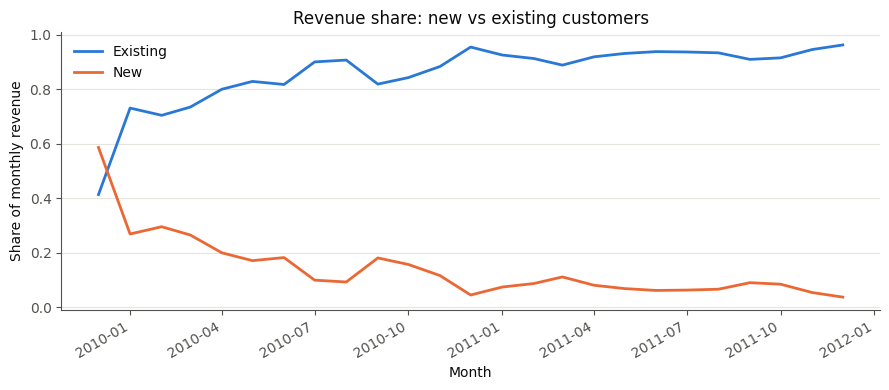

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    monthly_revenue_share.index,
    monthly_revenue_share["existing"],
    color=COLOR_EXISTING,
    linewidth=2,
    label="Existing",
)
ax.plot(
    monthly_revenue_share.index,
    monthly_revenue_share["new"],
    color=COLOR_NEW,
    linewidth=2,
    label="New",
)
ax.set_ylabel("Share of monthly revenue")
ax.set_xlabel("Month")
ax.set_title("Revenue share: new vs existing customers")
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6.7 Repeat Customer Analysis

In [ ]:
occasion_counts = occasions.groupby("customer_id").size()
is_repeat = occasion_counts > 1
customer_revenue = occasions.groupby("customer_id")["revenue"].sum()

repeat_summary = pd.DataFrame(
    {
        "customers": [(~is_repeat).sum(), is_repeat.sum()],
        "orders": [
            occasion_counts[~is_repeat].sum(),
            occasion_counts[is_repeat].sum(),
        ],
        "revenue": [
            customer_revenue[~is_repeat].sum(),
            customer_revenue[is_repeat].sum(),
        ],
    },
    index=["one_time", "repeat"],
)
repeat_summary["customer_share"] = (
    repeat_summary["customers"] / repeat_summary["customers"].sum()
)
repeat_summary["order_share"] = (
    repeat_summary["orders"] / repeat_summary["orders"].sum()
)
repeat_summary["revenue_share"] = (
    repeat_summary["revenue"] / repeat_summary["revenue"].sum()
)
repeat_summary.round(3)

,customers,orders,revenue,customer_share,order_share,revenue_share
one_time,1618,1618,555999.97,0.276,0.044,0.033
repeat,4234,34976,16512568.00,0.724,0.956,0.967


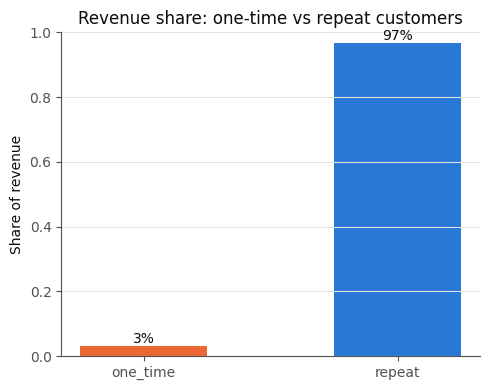

In [23]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    repeat_summary.index,
    repeat_summary["revenue_share"],
    color=[COLOR_NEW, COLOR_EXISTING],
    width=0.5,
)
ax.set_ylabel("Share of revenue")
ax.set_title("Revenue share: one-time vs repeat customers")
ax.set_ylim(0, 1)
for bar, share in zip(bars, repeat_summary["revenue_share"]):
    ax.annotate(
        f"{share:.0%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        color="#0b0b0b",
    )
fig.tight_layout()
plt.show()

## 6.8 Monthly Repurchase Analysis

In [24]:
first_occasion_month = occasions.groupby("customer_id")[
    "occasion_month"
].min()

months = sorted(occasions["occasion_month"].unique())
repurchase_rows = []
for month in months:
    eligible_customers = set(
        first_occasion_month[first_occasion_month < month].index
    )
    if not eligible_customers:
        continue
    buyers_this_month = set(
        occasions.loc[
            occasions["occasion_month"] == month, "customer_id"
        ]
    )
    repeat_buyers = len(buyers_this_month & eligible_customers)
    repurchase_rows.append(
        {
            "month": month,
            "eligible_existing": len(eligible_customers),
            "repeat_buyers": repeat_buyers,
            "repurchase_rate": repeat_buyers / len(eligible_customers),
        }
    )

monthly_repurchase = pd.DataFrame(repurchase_rows).set_index("month")
monthly_repurchase.round(3)

,eligible_existing,repeat_buyers,repurchase_rate
month,,,
2010-01-01,951,333,0.350
2010-02-01,1319,396,0.300
2010-03-01,1694,610,0.360
2010-04-01,2135,645,0.302
2010-05-01,2429,710,0.292
2010-06-01,2684,767,0.286
2010-07-01,2951,739,0.250
2010-08-01,3136,747,0.238
2010-09-01,3299,897,0.272


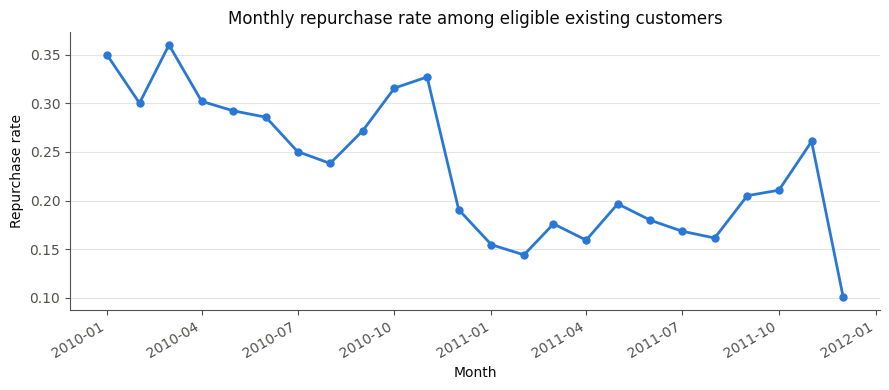

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    monthly_repurchase.index,
    monthly_repurchase["repurchase_rate"],
    color=COLOR_EXISTING,
    linewidth=2,
    marker="o",
    markersize=5,
)
ax.set_ylabel("Repurchase rate")
ax.set_xlabel("Month")
ax.set_title(
    "Monthly repurchase rate among eligible existing customers"
)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6.9 Inter-Purchase Interval

In [26]:
gap_days = inter_purchase_intervals(occasions)
gap_percentiles = gap_days.quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)
gap_summary = pd.concat(
    [gap_days.describe()[["mean", "std", "min", "max"]], gap_percentiles]
)
gap_summary.round(1)

mean     52.1
std      75.9
min       0.0
max     714.2
0.01      0.0
0.05      0.0
0.1       0.0
0.25      7.0
0.5      25.0
0.75     62.1
0.9     136.0
0.95    207.0
0.99    368.9
Name: invoice_time, dtype: float64

In [27]:
R_MAX_P90 = gap_days.quantile(0.90)
R_MAX_P95 = gap_days.quantile(0.95)
print(f"Candidate R_max (P90): {R_MAX_P90:.1f} days")
print(f"Candidate R_max (P95): {R_MAX_P95:.1f} days")

Candidate R_max (P90): 136.0 days
Candidate R_max (P95): 207.0 days


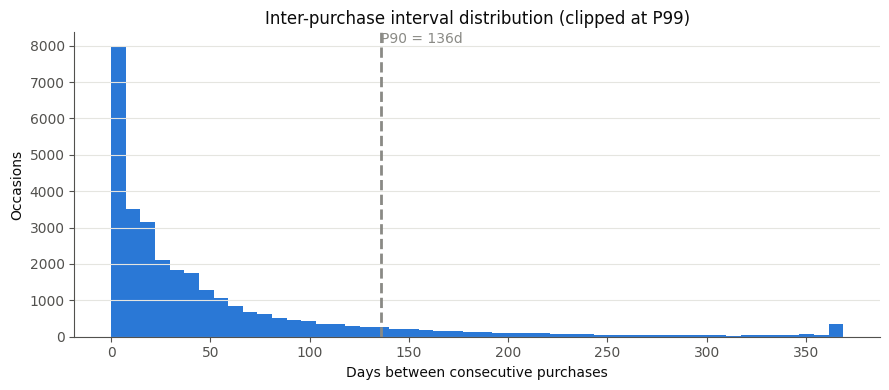

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    gap_days.clip(upper=gap_days.quantile(0.99)),
    bins=50,
    color=COLOR_EXISTING,
)
ax.axvline(
    R_MAX_P90, color=COLOR_NEUTRAL, linestyle="--", linewidth=2
)
ax.annotate(
    f"P90 = {R_MAX_P90:.0f}d",
    (R_MAX_P90, ax.get_ylim()[1]),
    ha="left",
    va="top",
    color=COLOR_NEUTRAL,
)
ax.set_xlabel("Days between consecutive purchases")
ax.set_ylabel("Occasions")
ax.set_title("Inter-purchase interval distribution (clipped at P99)")
fig.tight_layout()
plt.show()

## 6.10 Customer Monetary and Behavioral Analysis

In [29]:
customer_stats = occasions.groupby("customer_id").agg(
    revenue=("revenue", "sum"),
    frequency=("invoice_id", "nunique"),
)
customer_stats["aov"] = (
    customer_stats["revenue"] / customer_stats["frequency"]
)
customer_stats.describe().round(2)

,revenue,frequency,aov
count,5852.00,5852.00,5852.00
mean,2916.71,6.25,384.40
std,14306.85,12.75,1254.73
min,2.95,1.00,2.95
25%,339.58,1.00,176.14
50%,856.02,3.00,277.87
75%,2241.03,7.00,410.56
max,580987.04,373.00,84236.25


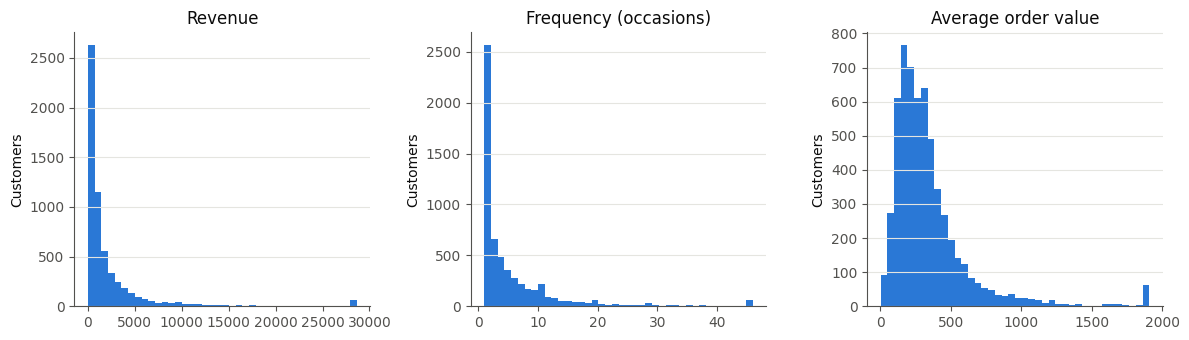

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
metrics = [
    ("revenue", "Revenue"),
    ("frequency", "Frequency (occasions)"),
    ("aov", "Average order value"),
]
for ax, (col, label) in zip(axes, metrics):
    ax.hist(
        customer_stats[col].clip(
            upper=customer_stats[col].quantile(0.99)
        ),
        bins=40,
        color=COLOR_EXISTING,
    )
    ax.set_title(label)
    ax.set_ylabel("Customers")
fig.tight_layout()
plt.show()

In [31]:
revenue_p99 = customer_stats["revenue"].quantile(0.99)
wholesale_like = customer_stats["revenue"] >= revenue_p99
wholesale_share = pd.Series(
    {
        "customer_share": wholesale_like.mean(),
        "revenue_share": (
            customer_stats.loc[wholesale_like, "revenue"].sum()
            / customer_stats["revenue"].sum()
        ),
    }
)
wholesale_share.round(3)

customer_share    0.010
revenue_share     0.321
dtype: float64

## 6.11 Customer Lifecycle

Stages are illustrative, based on recency as of the last observed
date and the P90 inter-purchase gap (R_max) from 6.9 -- not a
final definition.

In [32]:
data_end = occasions["invoice_time"].max()
last_purchase = occasions.groupby("customer_id")["invoice_time"].max()
recency_days = (
    (data_end - last_purchase).dt.total_seconds() / 86400
).reindex(customer_stats.index)

conditions = [
    customer_stats["frequency"] == 1,
    recency_days <= R_MAX_P90,
    recency_days <= 2 * R_MAX_P90,
]
choices = ["One-time", "Active repeat", "At-risk"]
stage = pd.Series(
    np.select(conditions, choices, default="Lapsed"),
    index=customer_stats.index,
    name="stage",
)

stage_order = ["One-time", "Active repeat", "At-risk", "Lapsed"]
lifecycle_summary = pd.DataFrame(
    {
        "customers": stage.value_counts(),
        "revenue": customer_stats["revenue"].groupby(stage).sum(),
    }
).reindex(stage_order)
lifecycle_summary.round(2)

,customers,revenue
stage,,
One-time,1618,555999.97
Active repeat,2787,14230318.20
At-risk,542,907995.16
Lapsed,905,1374254.64


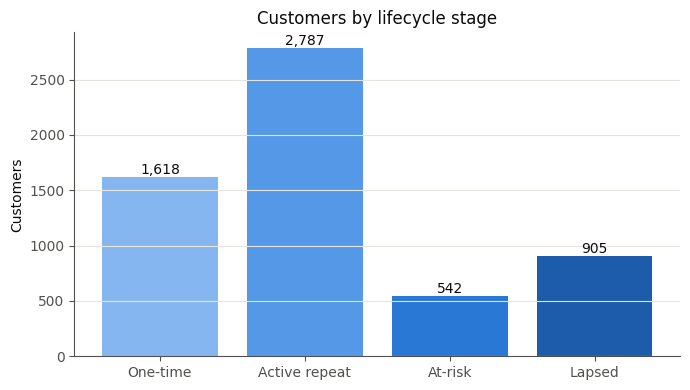

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    lifecycle_summary.index,
    lifecycle_summary["customers"],
    color=SEQUENTIAL_BLUES,
)
ax.set_ylabel("Customers")
ax.set_title("Customers by lifecycle stage")
for bar, count in zip(bars, lifecycle_summary["customers"]):
    ax.annotate(
        f"{count:,.0f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        color="#0b0b0b",
    )
fig.tight_layout()
plt.show()

## 6.12 RFM Exploration

In [34]:
rfm = pd.DataFrame(
    {
        "recency": recency_days,
        "frequency": customer_stats["frequency"],
        "monetary": customer_stats["revenue"],
    }
)
rfm.describe().round(2)

,recency,frequency,monetary
count,5852.00,5852.00,5852.00
mean,199.72,6.25,2916.71
std,208.52,12.75,14306.85
min,0.00,1.00,2.95
25%,25.00,1.00,339.58
50%,94.90,3.00,856.02
75%,378.85,7.00,2241.03
max,738.08,373.00,580987.04


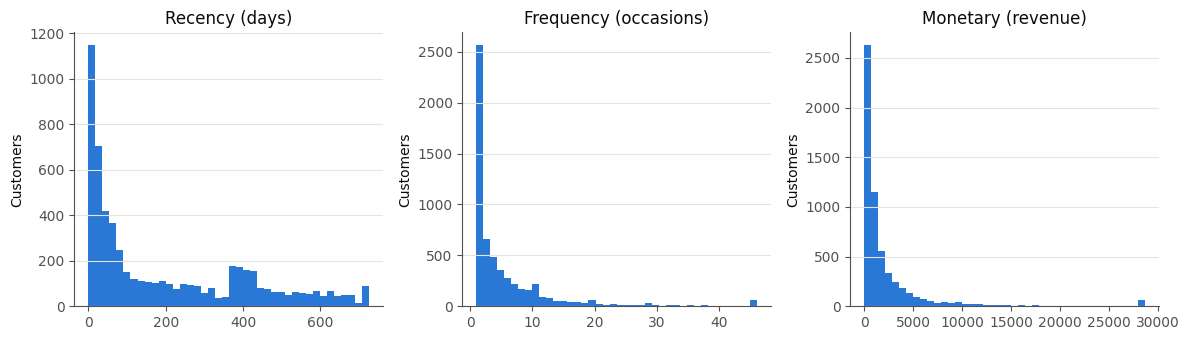

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
rfm_metrics = [
    ("recency", "Recency (days)"),
    ("frequency", "Frequency (occasions)"),
    ("monetary", "Monetary (revenue)"),
]
for ax, (col, label) in zip(axes, rfm_metrics):
    ax.hist(
        rfm[col].clip(upper=rfm[col].quantile(0.99)),
        bins=40,
        color=COLOR_EXISTING,
    )
    ax.set_title(label)
    ax.set_ylabel("Customers")
fig.tight_layout()
plt.show()

In [36]:
rfm["frequency_decile"] = (
    pd.qcut(rfm["frequency"].rank(method="first"), 10, labels=False)
    + 1
)
rfm.groupby("frequency_decile")[["recency", "monetary"]].mean().round(
    1
)

,recency,monetary
frequency_decile,,
1,335.1,409.8
2,358.4,308.0
3,330.0,461.7
4,243.2,935.6
5,212.2,1070.2
6,167.6,1241.6
7,142.8,1674.6
8,108.5,2474.0
9,64.4,3901.5


## 6.13 Churn Exploration (provisional labels)

Provisional labels only -- see the note in 6.1. Snapshots are
weekly Mondays, starting 6 months after the first purchase
(warm-up) through the last observed date. A customer is active if
recency <= R_max (P90, from 6.9). H = 90 days by default here.

In [37]:
WARMUP = pd.DateOffset(months=6)
DATA_START = occasions["invoice_time"].min()
DATA_END = occasions["invoice_time"].max()
H_DEFAULT = 90

warmup_end = DATA_START + WARMUP
weekly_dates = pd.date_range(
    start=warmup_end, end=DATA_END, freq="W-MON"
)
len(weekly_dates)

79

In [38]:
weekly_grid = build_snapshot_grid(occasions, weekly_dates, R_MAX_P90)
active_grid = weekly_grid[weekly_grid["is_active"]].copy()
active_grid.shape

(208751, 5)

In [39]:
labeled = add_provisional_labels(
    active_grid, occasions, H_DEFAULT, DATA_END
)
overall_churn_rate = labeled["churn"].mean()
print(
    f"Labelable active rows: {len(labeled):,} | "
    f"Provisional churn rate (H={H_DEFAULT}): "
    f"{overall_churn_rate:.1%}"
)

Labelable active rows: 172,550 | Provisional churn rate (H=90): 48.0%


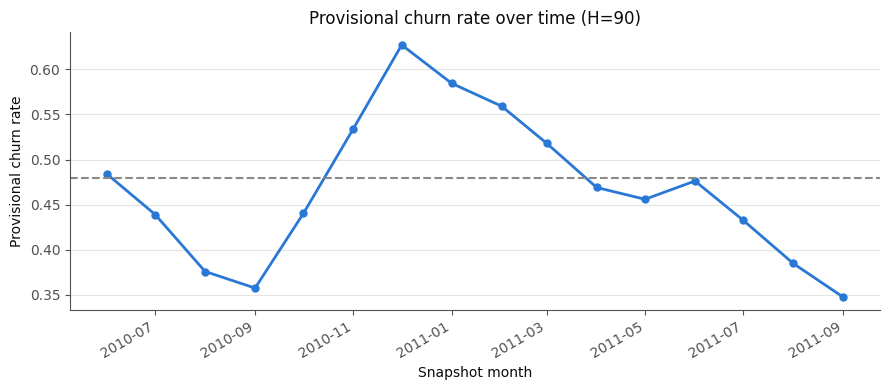

In [40]:
churn_by_month = (
    labeled.assign(
        snapshot_month=labeled["snapshot_date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("snapshot_month")["churn"]
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    churn_by_month.index,
    churn_by_month.values,
    color=COLOR_EXISTING,
    linewidth=2,
    marker="o",
    markersize=5,
)
ax.axhline(
    overall_churn_rate,
    color=COLOR_NEUTRAL,
    linestyle="--",
    linewidth=1.5,
)
ax.set_ylabel("Provisional churn rate")
ax.set_xlabel("Snapshot month")
ax.set_title(f"Provisional churn rate over time (H={H_DEFAULT})")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [41]:
labeled_rfm = labeled.merge(
    rfm[["recency", "frequency", "monetary"]],
    left_on="customer_id",
    right_index=True,
    how="left",
)
labeled_rfm["monetary_decile"] = (
    pd.qcut(
        labeled_rfm["monetary"].rank(method="first"), 10, labels=False
    )
    + 1
)
churn_by_monetary_decile = labeled_rfm.groupby("monetary_decile")[
    "churn"
].mean()
churn_by_monetary_decile.to_frame(
    "churn_rate"
).style.background_gradient(cmap="Blues").format("{:.1%}")

,churn_rate
monetary_decile,
1,93.7%
2,82.4%
3,68.4%
4,61.2%
5,52.0%
6,41.4%
7,33.8%
8,23.5%
9,15.0%


## 6.14 Snapshot Population and Design Feasibility

In [42]:
daily_dates = pd.date_range(start=warmup_end, end=DATA_END, freq="D")
daily_grid = build_snapshot_grid(occasions, daily_dates, R_MAX_P90)
daily_active = daily_grid[daily_grid["is_active"]]

scheme_comparison = pd.DataFrame(
    {
        "rows": [len(daily_active), len(active_grid), np.nan],
        "rows_per_customer": [
            len(daily_active) / daily_active["customer_id"].nunique(),
            len(active_grid) / active_grid["customer_id"].nunique(),
            np.nan,
        ],
    },
    index=["daily", "weekly_all", "weekly_episode"],
)
scheme_comparison.round(1)

,rows,rows_per_customer
daily,1477637.0,256.8
weekly_all,208751.0,36.5
weekly_episode,NaN,NaN


In [43]:
C_DEFAULT = H_DEFAULT
episode_grid = apply_episode_cooldown(active_grid, C_DEFAULT)

scheme_comparison.loc["weekly_episode", "rows"] = len(episode_grid)
scheme_comparison.loc["weekly_episode", "rows_per_customer"] = len(
    episode_grid
) / episode_grid["customer_id"].nunique()
scheme_comparison.round(1)

,rows,rows_per_customer
daily,1477637.0,256.8
weekly_all,208751.0,36.5
weekly_episode,20151.0,3.5


In [44]:
r_max_candidates = {"P90": R_MAX_P90, "P95": R_MAX_P95}
r_max_rows = []
for name, r_max in r_max_candidates.items():
    grid = build_snapshot_grid(occasions, weekly_dates, r_max)
    active = grid[grid["is_active"]]
    lab = add_provisional_labels(active, occasions, H_DEFAULT, DATA_END)
    r_max_rows.append(
        {
            "r_max_label": name,
            "r_max_days": round(r_max, 1),
            "active_rows": len(active),
            "active_customers": active["customer_id"].nunique(),
            "churn_rate": lab["churn"].mean(),
        }
    )
pd.DataFrame(r_max_rows).set_index("r_max_label").round(3)

,r_max_days,active_rows,active_customers,churn_rate
r_max_label,,,,
P90,136.0,208751,5725,0.480
P95,207.0,254540,5835,0.528


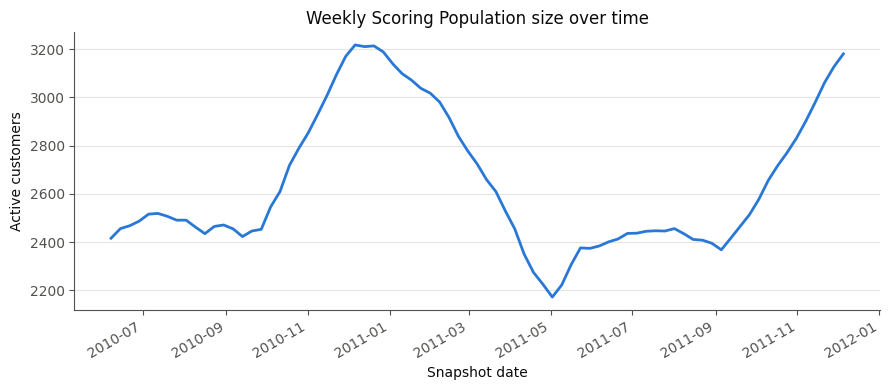

In [45]:
weekly_population = active_grid.groupby("snapshot_date")[
    "customer_id"
].nunique()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    weekly_population.index,
    weekly_population.values,
    color=COLOR_EXISTING,
    linewidth=2,
)
ax.set_ylabel("Active customers")
ax.set_xlabel("Snapshot date")
ax.set_title("Weekly Scoring Population size over time")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [46]:
def labelable_weekly_dates(h):
    """Weekly snapshot dates whose full H-day label window is
    observed.

    Args:
        h: Prediction horizon in days.

    Returns:
        A DatetimeIndex of labelable weekly snapshot dates.
    """
    return weekly_dates[
        weekly_dates + pd.Timedelta(days=h) <= DATA_END
    ]


def simulate_split_weeks(
    dates, horizon, target_val_weeks=8, target_test_weeks=10
):
    """Simulate a train/validation/test split with an embargo.

    Mirrors the embargoed split used in Chapter 7. Validation and
    test are sized to fixed operational targets and taken from the
    end of the labelable range working backward, with an embargo
    of `horizon` days before each; train absorbs whatever weeks
    remain before that. This avoids a fixed train fraction eating
    the whole range once two embargoes are subtracted from an
    already-short labelable window.

    Args:
        dates: Sorted DatetimeIndex of labelable weekly dates.
        horizon: Embargo length in days (H).
        target_val_weeks: Desired number of validation weeks.
        target_test_weeks: Desired number of test weeks.

    Returns:
        A dict with the count of weekly dates in each split.
    """
    embargo = pd.Timedelta(days=horizon)

    n_test = min(target_test_weeks, len(dates))
    test_dates = dates[-n_test:] if n_test else dates[:0]

    before_test = (
        dates[dates <= test_dates[0] - embargo]
        if len(test_dates)
        else dates
    )
    n_val = min(target_val_weeks, len(before_test))
    val_dates = before_test[-n_val:] if n_val else before_test[:0]

    train_dates = (
        before_test[before_test <= val_dates[0] - embargo]
        if len(val_dates)
        else before_test
    )

    return {
        "labelable_weeks": len(dates),
        "train_weeks": len(train_dates),
        "val_weeks": len(val_dates),
        "test_weeks": len(test_dates),
    }

In [47]:
feasibility_rows = []
for h in (60, 90, 120):
    dates = labelable_weekly_dates(h)
    result = simulate_split_weeks(dates, h)
    result["H"] = h
    result["meets_min_8_test_weeks"] = result["test_weeks"] >= 8
    feasibility_rows.append(result)

pd.DataFrame(feasibility_rows).set_index("H")

,labelable_weeks,train_weeks,val_weeks,test_weeks,meets_min_8_test_weeks
H,,,,,
60,71,37,8,10,True
90,66,24,8,10,True
120,62,10,8,10,True


## 6.15 Key Findings

**Revenue composition.** Repeat customers are 72.3% of customers
(4,234 of 5,852) but generate 96.7% of revenue and 95.6% of orders
-- existing-customer retention is where almost all the revenue
already is, which is the direct business case for this project.

**Heterogeneity.** Customer revenue is extremely right-skewed (mean
$2,917 vs. median $856). The top 1% of customers by revenue
("wholesale-like") are only 1.0% of customers but 32.1% of revenue
-- consistent with Online Retail II's known mix of UK retail and
wholesale buyers (Section 5.5).

**Repeat purchasing.** The monthly repurchase rate among eligible
existing customers averages 23.3% (range 10.1%-36.0% across 24
months) -- noisier month to month than seasonal, unlike raw revenue
which clearly peaks in Nov 2010 and dips in Feb 2011.

**Purchase intervals -> R_max.** Gaps between consecutive purchases
are highly skewed: median 25 days, mean 52 days, P90 = 136 days,
P95 = 207 days. These set the $R_{\max}$ candidates used throughout
this notebook (136 / 207 days).

**Churn behavior.** At $H=90$ days and $R_{\max}=$ P90, the
provisional churn rate is **48.0%** across 172,550 labelable active
snapshot rows -- churn is close to a majority class here, not a
rare event, exactly the scenario Section 3.14/Chapter 9 warn about
for reading PR-AUC and Precision. Loosening the activity threshold
to $R_{\max}=$ P95 admits more marginal customers and pushes the
observed rate up to 52.8%, so the final $R_{\max}$ choice will
materially change the label distribution.

**Snapshot design feasibility.** Weekly-all active population is
stable (mean ~2,642 customers/week, range 2,172-3,218 over 79
weeks). The episode-cooldown rule (C=90) cuts training rows from
208,751 (weekly-all) to 20,151 -- a >90% reduction, as intended. A
daily grid would carry 1,477,637 rows (~7.1x weekly-all), confirming
the cost of daily snapshots. For the embargoed split (8 validation
/ 10 test weeks, matching Section 7.9's illustration): train weeks
fall sharply as $H$ grows -- 37 ($H=60$), 24 ($H=90$), only 10
($H=120$) -- because the ~2-year span leaves little slack once two
$H$-day embargoes are subtracted. All three candidates clear the
>=8 test-week bar, but $H=120$'s 10 training weeks is too thin to
be practical; **$H=90$ (24 train weeks) is the best-supported
choice**, matching the illustrative timeline already used in
Chapter 7.

**Data limitations.** 22.8% of raw rows have no Customer ID (the
single largest data-quality issue, ahead of duplicates at 3.2%,
invalid quantity/price at 2.4%, cancellations at 1.8%, and
non-product codes at 0.6%) and are necessarily excluded from any
customer-level analysis. Combined, the valid-transaction rules keep
72.8% of raw rows for analysis -- consistent with Section 7.2's
definition, applied here provisionally.